Supervised Learning -
1. Regression - Prediciting continios value
2. Classification - Used when answer is category A or B , Results are distint

Goal is Predict specific Output and feedback is direct to the Machine

Unsupervised Learning 
1. Will find hidden similarities, difference and will end up ****Clustering****

Goal is finding Hidden features

ML Pipeline

1. Define the problem - Define clear Success Matrix, Identify the Traget Variable, Map out required input features
2. Data Collection - Structured, Unstructured, Real-time Streams
3. Data Preprocessing - Basic EDA (Missing values, Outliers, Encoding etc)
4. Feature Engineering - (Extraction, Scaling, Selection)
5. Train Test Split
6. Learning - Model Training (Linear Regression, Random Forest, XGBoost)
7. The Verdict (Accuracy, Precision, Recall)
8. Hyperparameter Tuning
9. Delivery and Monitoring

Simple linear Regression

y^ = w . x + b (w = weight , b =bias)

In [3]:
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 
import pandas as pd

In [35]:
X = np.array([1,3,4,6,7]) 
y = np.array([15,35,45,65,70]) 

<Axes: >

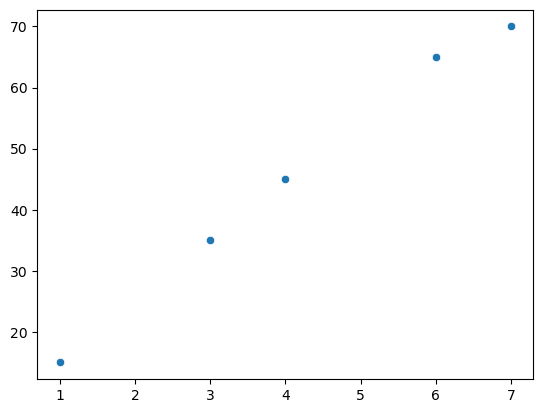

In [36]:
sns.scatterplot(x= X, y= y)

In [37]:
def make_prediction(X, y, w ,b):
    m = X.shape[0]
    pred_list = np.zeros((m,))
    for i in range(m):
        pred_list[i] = w * X[i] + b

    return pred_list

[0. 0. 0. 0. 0.]


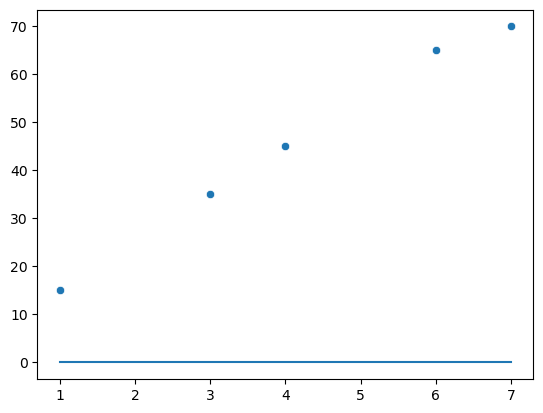

In [38]:
predictions = make_prediction(X,y,0,0) 
print(predictions)
sns.scatterplot(x= X, y= y)
plt.plot(X, predictions)

[15. 35. 45. 65. 75.]


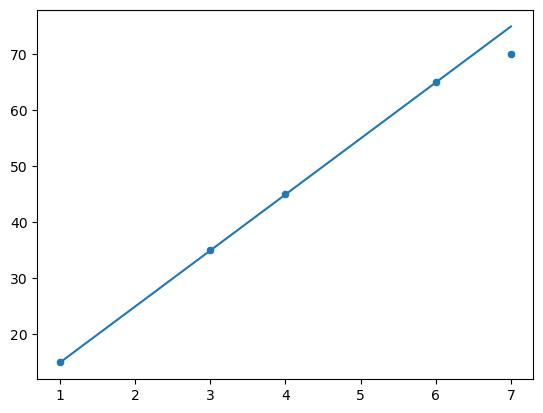

In [39]:
predictions = make_prediction(X,y,w=10,b=5) 
print(predictions)
sns.scatterplot(x= X, y= y)
plt.plot(X, predictions)

In [40]:
def compute_cost(X,y,w,b):
    m = X.shape[0] # number data points
    cost = 0.0 
    pred_list= np.zeros((m,))

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        error = error ** 2
        cost = cost + error 

    cost = cost /m 
    return cost


    

Mean square fucntion

[15. 35. 45. 65. 75.]


Text(0.5, 1.0, 'Cost: 5.0, for w=10.0 and b=5.0')

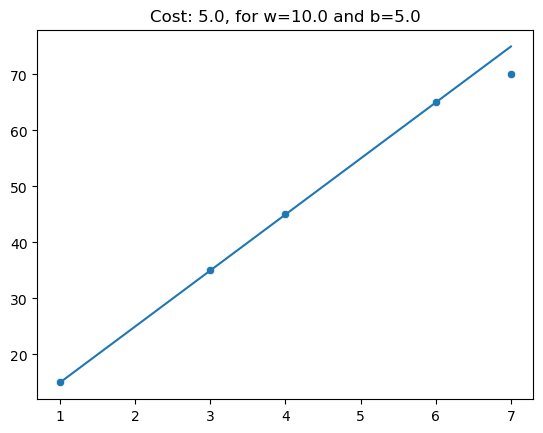

In [41]:
w=10.0 
b=5.0
predictions = make_prediction(X,y,w=w,b=b) 
print(predictions)
sns.scatterplot(x= X, y= y)
plt.plot(X, predictions)
plt.title(f"Cost: {compute_cost(X,y,w=w,b=b)}, for w={w} and b={b}")

Text(0, 0.5, 'Cost - J(w)')

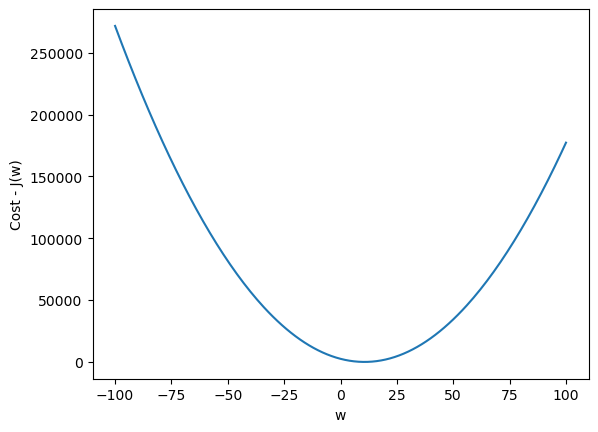

In [42]:
w =[] 
cost =[] 

for i in range(-100,101):
    cost_i = compute_cost(X,y,w=i,b=0)
    w.append(i) 
    cost.append(cost_i) 

plt.plot(w,cost) #convex fucntion 
plt.xlabel("w") 
plt.ylabel("Cost - J(w)") 
    

Gradient Descent

In [43]:
def calculate_gradient(X,y,w,b):
    m = X.shape[0] # number data points
    dj_dw = 0.0 
    dj_db=0.0

    for i in range(m):
        prediction = w * X[i] + b
        error = prediction - y[i]
        dj_dw = dj_dw + (error * X[i])
        dj_db = dj_db + (error) 

    dj_dw = dj_dw / m 
    dj_db = dj_db / m  

    return dj_dw,dj_db  



    
  

    

In [44]:
calculate_gradient(X,y,w=3,b=0)

(np.float64(-169.4), np.float64(-33.4))

Applyting Gradient Descent 

In [45]:
def gradient_descent(X,y,w_input,b_input, max_iter, alpha=0.01):

    w=w_input
    b=b_input
    cost_memo =[] 
    iteration =[]
    for i in range(max_iter):
        dj_dw,dj_db = calculate_gradient(X,y,w,b)
        #update
        w = w - (alpha * dj_dw) 
        b= b- (alpha * dj_db)
        cost = (compute_cost(X,y,w,b)) 
        cost_memo.append(cost)
        iteration.append(i)

        if i%100 ==0:
            print(f"iteration:{iteration[i]}, w:{w},b:{b}, dj_dw:{dj_dw}, dj_dwb:{dj_db}, cost:{cost}") 

    return w,b,cost_memo,iteration
        
    
    
    

In [46]:
w,b,cost_memo,iteration = gradient_descent(X,y,w_input=0,b_input=0, max_iter=10000, alpha=0.01)

iteration:0, w:2.36,b:0.46, dj_dw:-236.0, dj_dwb:-46.0, cost:1496.73576
iteration:100, w:10.1075492068144,b:2.798918720681244, dj_dw:0.1433351737902953, dj_dwb:-0.7508631650495747, cost:5.2165826187218505
iteration:200, w:9.97766901757153,b:3.4792977698706853, dj_dw:0.11753583333801743, dj_dwb:-0.6157129811400897, cost:4.254821302246764
iteration:300, w:9.871166365323983,b:4.037213289353866, dj_dw:0.0963801951183477, dj_dwb:-0.5048888970610484, cost:3.6081220991919905
iteration:400, w:9.783833454902354,b:4.494707868668273, dj_dw:0.07903242566322746, dj_dwb:-0.41401238269089297, cost:3.173274229905158
iteration:500, w:9.712219865177055,b:4.869856583470024, dj_dw:0.06480713489468286, dj_dwb:-0.3394930132533062, cost:2.8808775970809832
iteration:600, w:9.6534962269909,b:5.177481120635717, dj_dw:0.053142298215117026, dj_dwb:-0.27838661563380923, cost:2.684266789197441
iteration:700, w:9.605342438093482,b:5.429735365772646, dj_dw:0.043577051572694356, dj_dwb:-0.2282789475441181, cost:2.5520

In [47]:
print(w,b)

9.385964914404349 6.5789473572963


[15.96491227 34.7368421  44.12280701 62.89473684 72.28070176]


Text(0.5, 1.0, 'Cost: 2.280701754385957, for w=9.385964914404349 and b=6.5789473572963')

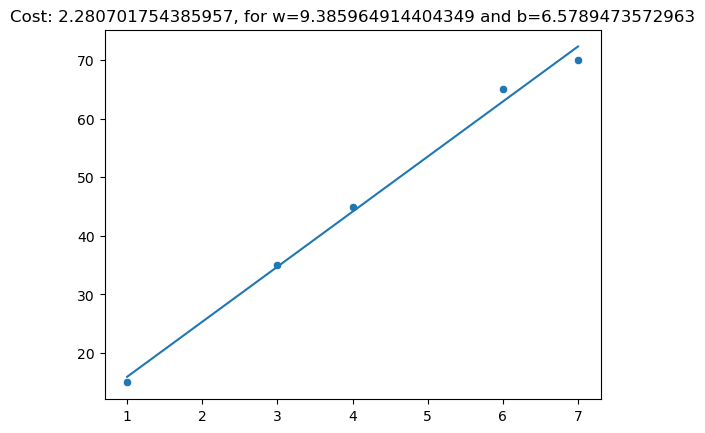

In [48]:
predictions = make_prediction(X,y,w=w,b=b) 
print(predictions)
sns.scatterplot(x= X, y= y)
plt.plot(X, predictions)
plt.title(f"Cost: {compute_cost(X,y,w=w,b=b)}, for w={w} and b={b}")

In [49]:
# jar 2 bochor experience tar salary koto 

predictions= w * 2 + b
print(predictions)

25.350877186105


Text(0, 0.5, 'cost')

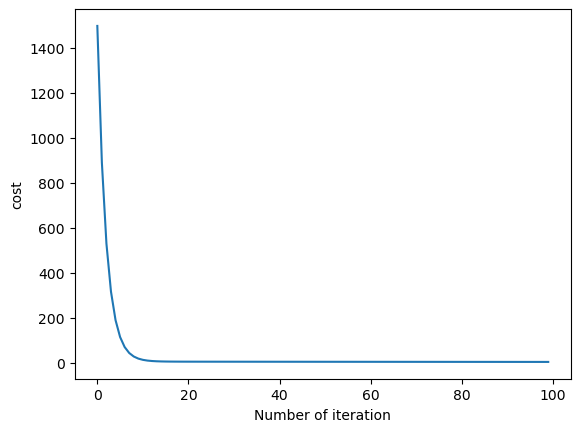

In [54]:
plt.plot(iteration[:100],cost_memo[:100])
plt.xlabel("Number of iteration") 
plt.ylabel("cost")

# Practice problem

In [4]:
df = pd.read_csv('Housing.csv')
df

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished
...,...,...,...,...,...,...,...,...,...,...,...,...,...
540,1820000,3000,2,1,1,yes,no,yes,no,no,2,no,unfurnished
541,1767150,2400,3,1,1,no,no,no,no,no,0,no,semi-furnished
542,1750000,3620,2,1,1,yes,no,no,no,no,0,no,unfurnished
543,1750000,2910,3,1,1,no,no,no,no,no,0,no,furnished


In [7]:
X= df['bedrooms'].to_numpy() 
y= df['price'].to_numpy()
print(X) , print(y)

[4 4 3 4 4 3 4 5 4 3 3 4 4 4 3 4 4 3 3 3 3 3 3 3 3 4 3 3 5 4 3 3 4 3 5 3 3
 4 3 4 3 3 3 4 4 3 3 3 3 3 3 3 4 3 3 3 4 4 4 3 3 2 4 4 3 3 2 3 3 4 3 4 3 2
 3 4 3 3 3 3 3 3 3 3 3 3 3 3 3 5 3 2 3 3 4 3 3 3 3 4 3 3 3 3 3 3 4 3 4 4 3
 3 6 3 2 3 3 4 3 3 3 3 4 4 3 3 3 3 3 3 3 4 3 3 3 3 4 4 3 3 3 4 4 5 4 3 2 3
 3 4 3 4 5 3 3 3 3 4 3 3 4 3 4 3 3 3 3 2 4 4 3 3 3 4 3 4 3 3 3 3 4 3 3 3 3
 3 2 3 2 2 4 3 3 2 3 4 3 3 3 3 3 3 2 4 3 3 2 3 3 3 3 3 4 4 2 3 3 3 2 3 4 4
 2 3 2 2 3 2 3 4 2 3 3 3 3 3 2 3 4 3 3 3 3 3 3 3 3 4 2 4 3 3 3 2 4 2 3 3 3
 2 3 3 2 3 2 3 3 3 4 3 3 5 3 4 4 2 2 2 3 2 2 2 3 4 2 3 3 3 3 2 4 3 4 2 4 3
 3 3 3 3 3 3 3 3 3 3 3 3 3 4 3 2 3 3 2 2 4 3 3 4 3 3 3 3 3 4 4 3 3 3 2 3 4
 3 2 2 3 4 2 4 5 2 3 2 2 3 2 3 2 3 2 2 2 3 2 3 5 4 2 3 2 3 2 2 3 2 2 2 2 2
 2 3 3 2 2 3 3 3 3 3 2 2 3 4 2 2 3 3 3 4 3 3 3 3 3 6 2 2 3 2 2 3 2 3 3 3 2
 3 2 2 3 3 3 3 2 3 3 2 4 4 2 2 2 3 3 2 3 3 2 4 2 4 3 4 4 2 3 3 2 2 4 3 2 3
 3 1 2 2 2 3 3 2 3 2 3 3 3 3 3 2 2 2 3 2 2 2 3 3 2 2 3 3 4 2 4 2 3 2 3 4 3
 2 3 3 2 2 2 4 4 3 3 2 3 

(None, None)

In [12]:
def make_prediction(X,y,w,b):
     m = X.shape[0] 
     pred_list = np.zeros((m,))
     for i in range(m):
         pred_list[i] = w * X[i] + b 

     return pred_list
         
         
    

def msf(X,y,w,b):
    m = X.shape[0] 
    cost = 0.0
    for i in range(m):
        pred=  w * X[i] + b 
        error = pred - y[i] 
        error = error ** 2
        cost = cost + error

    cost = cost/m 
    return cost

[4. 4. 3. 4. 4. 3. 4. 5. 4. 3. 3. 4. 4. 4. 3. 4. 4. 3. 3. 3. 3. 3. 3. 3.
 3. 4. 3. 3. 5. 4. 3. 3. 4. 3. 5. 3. 3. 4. 3. 4. 3. 3. 3. 4. 4. 3. 3. 3.
 3. 3. 3. 3. 4. 3. 3. 3. 4. 4. 4. 3. 3. 2. 4. 4. 3. 3. 2. 3. 3. 4. 3. 4.
 3. 2. 3. 4. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 5. 3. 2. 3. 3. 4. 3.
 3. 3. 3. 4. 3. 3. 3. 3. 3. 3. 4. 3. 4. 4. 3. 3. 6. 3. 2. 3. 3. 4. 3. 3.
 3. 3. 4. 4. 3. 3. 3. 3. 3. 3. 3. 4. 3. 3. 3. 3. 4. 4. 3. 3. 3. 4. 4. 5.
 4. 3. 2. 3. 3. 4. 3. 4. 5. 3. 3. 3. 3. 4. 3. 3. 4. 3. 4. 3. 3. 3. 3. 2.
 4. 4. 3. 3. 3. 4. 3. 4. 3. 3. 3. 3. 4. 3. 3. 3. 3. 3. 2. 3. 2. 2. 4. 3.
 3. 2. 3. 4. 3. 3. 3. 3. 3. 3. 2. 4. 3. 3. 2. 3. 3. 3. 3. 3. 4. 4. 2. 3.
 3. 3. 2. 3. 4. 4. 2. 3. 2. 2. 3. 2. 3. 4. 2. 3. 3. 3. 3. 3. 2. 3. 4. 3.
 3. 3. 3. 3. 3. 3. 3. 4. 2. 4. 3. 3. 3. 2. 4. 2. 3. 3. 3. 2. 3. 3. 2. 3.
 2. 3. 3. 3. 4. 3. 3. 5. 3. 4. 4. 2. 2. 2. 3. 2. 2. 2. 3. 4. 2. 3. 3. 3.
 3. 2. 4. 3. 4. 2. 4. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 4. 3. 2.
 3. 3. 2. 2. 4. 3. 3. 4. 3. 3. 3. 3. 3. 4. 4. 3. 3.

Text(0.5, 1.0, 'Cost: 26213492282754.973, for w=10.0 and b=5.0')

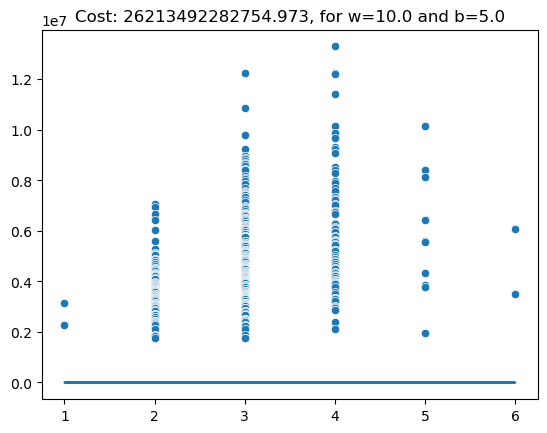

In [16]:
w=10.0 
b=5.0
predictions = make_prediction(X,y,w=1,b=0) 
print(predictions)
sns.scatterplot(x= X, y= y)
plt.plot(X, predictions)
plt.title(f"Cost: {msf(X,y,w=w,b=b)}, for w={w} and b={b}")

In [18]:
 w = np.random.randn() 
 b = np.random.randn() 

print(f"Initial w, {w}")
print(f"Initial b, {b}")  

initial_cost = msf(X,y,w,b) 
print(initial_cost)

Initial w, -3.4238074987126423
Initial b, -1.1132380047847785
26213943584876.016


In [21]:
def gradient(X,y,w,b):
    m = X.shape[0]
    dj_dw = 0.0
    dj_db =0.0 

    for i in range(m):
        predictions = w * X[i] + b 
        error = predictions - y[i] 
        dj_dw = dj_dw + (error * X[i]) 
        dj_db = error 

    dj_dw = dj_dw / m
    dj_db = dj_db / m  
    return dj_dw, dj_db  



In [22]:
def gradient_descet(X,y, w,b, iterr, alpha):
    cost = []
    iterations = []
    for i in range(iterr):
        dj_dw,dj_db = gradient_descet(X,y,w,b) 
        w= w - (alpha * dj_dw) 
        b = b - (alpha * dj_db) 
        cost.append(msf(X,y,w,b)) 
        iterations.append(i) 

    return w, b, cost , iterations
        
        

In [25]:
w , b , cost , iterations = gradient_descet(X,y, w=0,b=0, iterr=1000, alpha=0.01)
print(f" Calculated weight {w}")
print(f" Calculated bias {b}")
plt.plot(iterations,cost) 

plt.xlabel("Number of iterations")
plit.ylabel("cost ")

TypeError: gradient_descet() missing 2 required positional arguments: 'iterr' and 'alpha'